# Wisconsin Breast Cancer Dataset

In [1]:
# ── 0. Imports ─────────────────────────────────────────────────────────────────
import numpy as np
from sklearn.datasets import load_breast_cancer
 
from config.config import N_QUBITS, N_LAYERS, N_POINTS, N_TRIALS, N_EPOCH, N_POPSIZE, N_PM, SEED
from config.experiments import ExperimentConfig
 
from src.data.preprocessing import preprocess
import src.data.saving as saving
from src.data.saving import candidate_exists, svm_exists, load_parameter_train, load_svm_results
from src.kernel.quantum_kernel import quantum_kernel_matrix_cross
from src.optimization.pipeline import get_candidate, get_svm_results
from src.optimization.classical_base import classical_baseline
import src.utils.visuals as visuals
from src.utils.visuals import plot_accuracy, plot_g_best, plot_kernel_heatmaps

from src.data.subsets import subset_random, subset_nystrom_global, subset_nystrom_stratified
from src.utils.visuals import graph_subset

In [2]:
# ── 1. Data ────────────────────────────────────────────────────────────────────

dataset = load_breast_cancer()
X_train, X_test, y_train, y_test = preprocess(dataset.data, dataset.target, N_QUBITS)

print(f"Dataset  : {dataset.target_names}")
print(f"Train    : {X_train.shape}  |  Test: {X_test.shape}")

RESULTS_DIR = 'Results/Wisconsin breast dataset'
saving.RESULTS_DIR = RESULTS_DIR
visuals.RESULTS_DIR = RESULTS_DIR

Dataset  : ['malignant' 'benign']
Train    : (398, 4)  |  Test: (171, 4)


In [3]:
# ── 2. Experiments ─────────────────────────────────────────────────────────────
# This is the main section to edit. Each ExperimentConfig defines one run.
# Comment out any you don't want to include.
#
# name             → used as the Results subfolder name; must be unique
# optimizer        → 'optuna' or 'mealpy'
# subset_method    → 'random', 'nystrom_global', or 'nystrom_stratified'
# subset_kwargs    → passed to the chosen subset function
# optimizer_kwargs → passed to the chosen optimizer
# load_from        → (optional) load candidate from a different experiment name

EXPERIMENTS: list[ExperimentConfig] = [
 
    # ── OPTUNA ────────────────────────────────────────────────────────────────
    ExperimentConfig(
        name             = 'optuna_random',
        optimizer        = 'optuna',
        subset_method    = 'random',
        subset_kwargs    = {'n_sample': N_POINTS, 'seed': SEED},
        optimizer_kwargs = {'n_trials': N_TRIALS},
    ),
    ExperimentConfig(
        name             = 'optuna_nystrom_global',
        optimizer        = 'optuna',
        subset_method    = 'nystrom_global',
        subset_kwargs    = {'n_qubits': N_QUBITS, 'n_landmarks': N_POINTS},
        optimizer_kwargs = {'n_trials': N_TRIALS},
    ),
    ExperimentConfig(
        name             = 'optuna_nystrom_stratified',
        optimizer        = 'optuna',
        subset_method    = 'nystrom_stratified',
        subset_kwargs    = {'n_qubits': N_QUBITS, 'n_pos': N_POINTS // 2, 'n_neg': N_POINTS // 2},
        optimizer_kwargs = {'n_trials': N_TRIALS},
    ),
 
    # ── Mealpy ────────────────────────────────────────────────────────────────
    ExperimentConfig(
        name             = 'mealpy_random',
        optimizer        = 'mealpy',
        subset_method    = 'random',
        subset_kwargs    = {'n_sample': N_POINTS, 'seed': SEED},
        optimizer_kwargs = {'n_epoch': N_EPOCH, 'n_pop_size': N_POPSIZE, 'n_pm': N_PM},
    ),
    ExperimentConfig(
        name             = 'mealpy_nystrom_global',
        optimizer        = 'mealpy',
        subset_method    = 'nystrom_global',
        subset_kwargs    = {'n_qubits': N_QUBITS, 'n_landmarks': N_POINTS},
        optimizer_kwargs = {'n_epoch': N_EPOCH, 'n_pop_size': N_POPSIZE, 'n_pm': N_PM},
    ),
    ExperimentConfig(
        name             = 'mealpy_nystrom_stratified',
        optimizer        = 'mealpy',
        subset_method    = 'nystrom_stratified',
        subset_kwargs    = {'n_qubits': N_QUBITS, 'n_pos': N_POINTS // 2, 'n_neg': N_POINTS // 2},
        optimizer_kwargs = {'n_epoch': N_EPOCH, 'n_pop_size': N_POPSIZE, 'n_pm': N_PM},
    ),
 
]

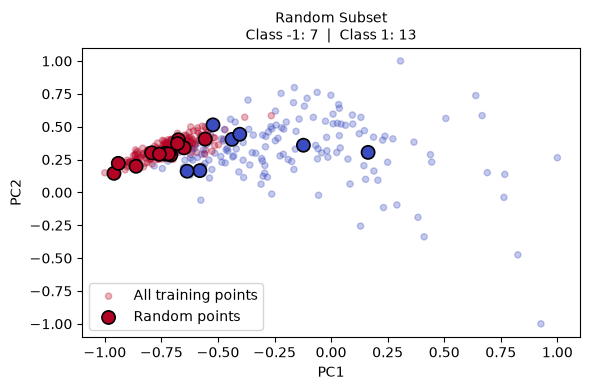

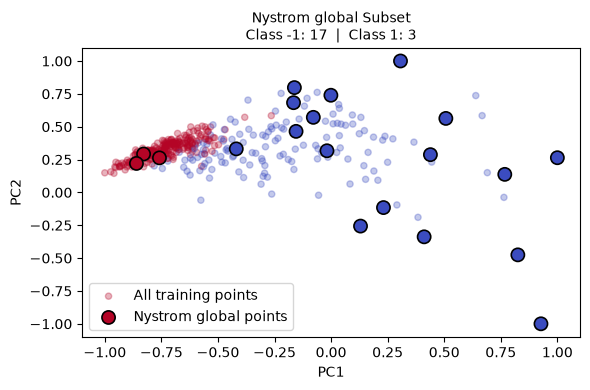

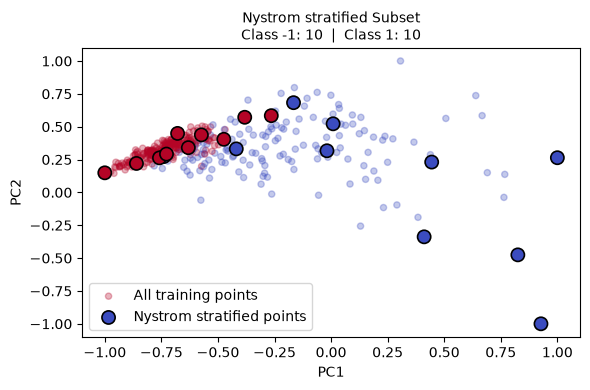

In [3]:
# Dataset structure
_, X_random, y_random = subset_random(X_train, y_train, N_POINTS, SEED)
graph_subset('Random', X_train, X_random, y_train, y_random)

_, X_global, y_global = subset_nystrom_global(X_train, y_train, N_QUBITS, N_POINTS)
graph_subset('Nystrom global', X_train, X_global, y_train, y_global)

_, X_stratified, y_stratified = subset_nystrom_stratified(X_train, y_train, N_QUBITS, 10)
graph_subset('Nystrom stratified', X_train, X_stratified, y_train, y_stratified)

In [4]:
# ── 3. Run ─────────────────────────────────────────────────────────────────────
# Cached results are reused automatically; delete Results/{name}/svm.pkl or
# Results/{name}/candidate.pkl to force a fresh run for that experiment.
 
summary = {}   # name → {accuracy, cv_acc, g_best, best_C}
 
# ── Classical baseline ──────────────────────────────────────────────────────
BASELINE = 'Classical_baseline'
if svm_exists(BASELINE):
    print(f"\nLoaded results of SVM for '{BASELINE}'")
    baseline_res = load_svm_results(BASELINE)
else:
    baseline_res = classical_baseline(X_train, y_train, X_test, y_test, name=BASELINE)
 
summary[BASELINE] = {
    'accuracy': baseline_res['accuracy'],
    'cv_acc':   float(baseline_res['best_cv_accuracy']),
    'best_C':   baseline_res['best_C'],
    'g_best':   float('nan'),
}
 
# ── Quantum experiments ─────────────────────────────────────────────────────
for config in EXPERIMENTS:
    print(f"\n{'─' * 60}")
    print(f" {config.name}  [{config.optimizer} + {config.subset_method}]")
    print(f"{'─' * 60}")
 
    # Step 1: Candidate (train or load from cache)
    candidate, K_train, K_classical, X_sub, y_sub = get_candidate(config, X_train, y_train)
    g_best = load_parameter_train(config.name).get('g_best', float('nan'))
 
    # Step 2: SVM (run or load from cache)
    K_test = None
    if not svm_exists(config.name):
        print("Computing cross-kernel (test × subset)…")
        K_test = quantum_kernel_matrix_cross(X_test, X_sub, candidate)
 
    results = get_svm_results(config, K_train, y_sub, K_test, y_test)
 
    summary[config.name] = {
        'accuracy': results['accuracy'],
        'cv_acc':   float(results['best_cv_accuracy']),
        'best_C':   results['best_C'],
        'g_best':   g_best,
    }


Loaded results of SVM for 'Classical_baseline'

────────────────────────────────────────────────────────────
 optuna_random  [optuna + random]
────────────────────────────────────────────────────────────
Loading cached candidate for 'optuna_random'
Loading cached SVM results for 'optuna_random'

────────────────────────────────────────────────────────────
 optuna_nystrom_global  [optuna + nystrom_global]
────────────────────────────────────────────────────────────
Loading cached candidate for 'optuna_nystrom_global'
Loading cached SVM results for 'optuna_nystrom_global'

────────────────────────────────────────────────────────────
 optuna_nystrom_stratified  [optuna + nystrom_stratified]
────────────────────────────────────────────────────────────
Loading cached candidate for 'optuna_nystrom_stratified'
Loading cached SVM results for 'optuna_nystrom_stratified'

────────────────────────────────────────────────────────────
 mealpy_random  [mealpy + random]
─────────────────────────────

In [5]:
# ── 4. Summary table ───────────────────────────────────────────────────────────
 
def print_summary(summary: dict) -> None:
    W = 32
    print(f"\n{'═' * 68}")
    print(f"  {'EXPERIMENT':<{W}} {'TEST ACC':>9} {'CV ACC':>9} {'g_best':>9} {'best C':>6}")
    print(f"{'─' * 68}")
    for name, s in summary.items():
        g = f"{s['g_best']:9.2f}" if not np.isnan(s['g_best']) else f"{'—':>9}"
        print(f"  {name:<{W}} {s['accuracy']:>9.4f} {s['cv_acc']:>9.4f} {g} {s['best_C']:>6}")
    print(f"{'═' * 68}\n")
 
print_summary(summary)


════════════════════════════════════════════════════════════════════
  EXPERIMENT                        TEST ACC    CV ACC    g_best best C
────────────────────────────────────────────────────────────────────
  Classical_baseline                  0.9649    0.9547         —   1000
  optuna_random                       0.6023    0.6500     71.66     10
  optuna_nystrom_global               0.3684    0.9000      8.76    0.1
  optuna_nystrom_stratified           0.5906    0.5500     37.33    0.1
  mealpy_random                       0.7836    0.9000     37.83    100
  mealpy_nystrom_global               0.3684    0.9000      8.32    0.1
  mealpy_nystrom_stratified           0.7895    0.9000     18.11      1
════════════════════════════════════════════════════════════════════



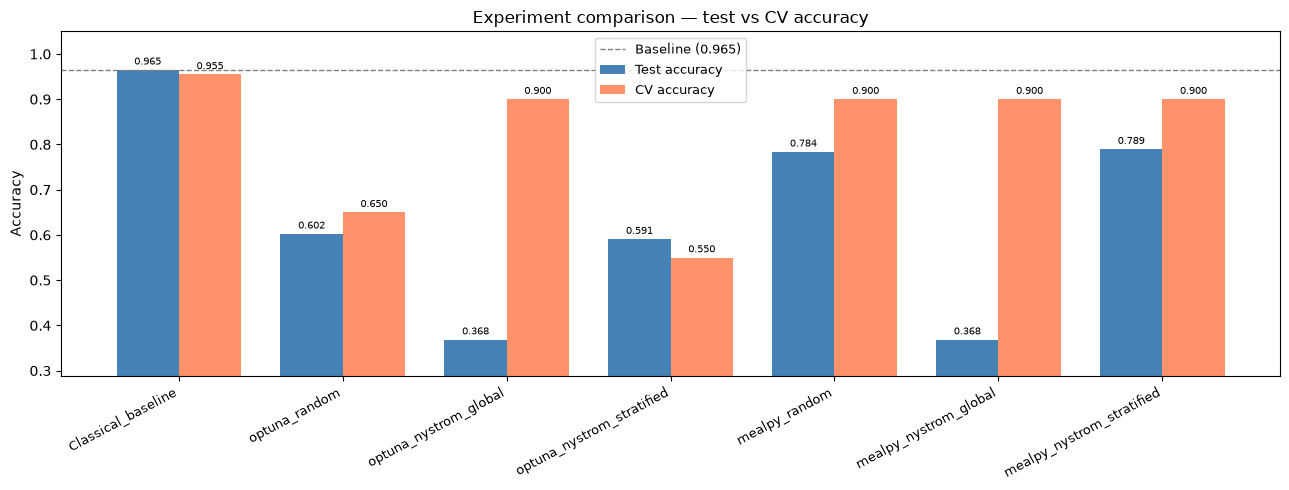

Saved → Results/Wisconsin breast dataset/accuracy_comparison.png


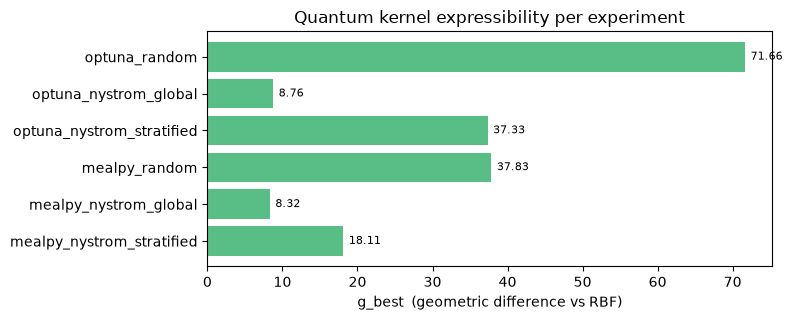

Saved → Results/Wisconsin breast dataset/g_best_comparison.png


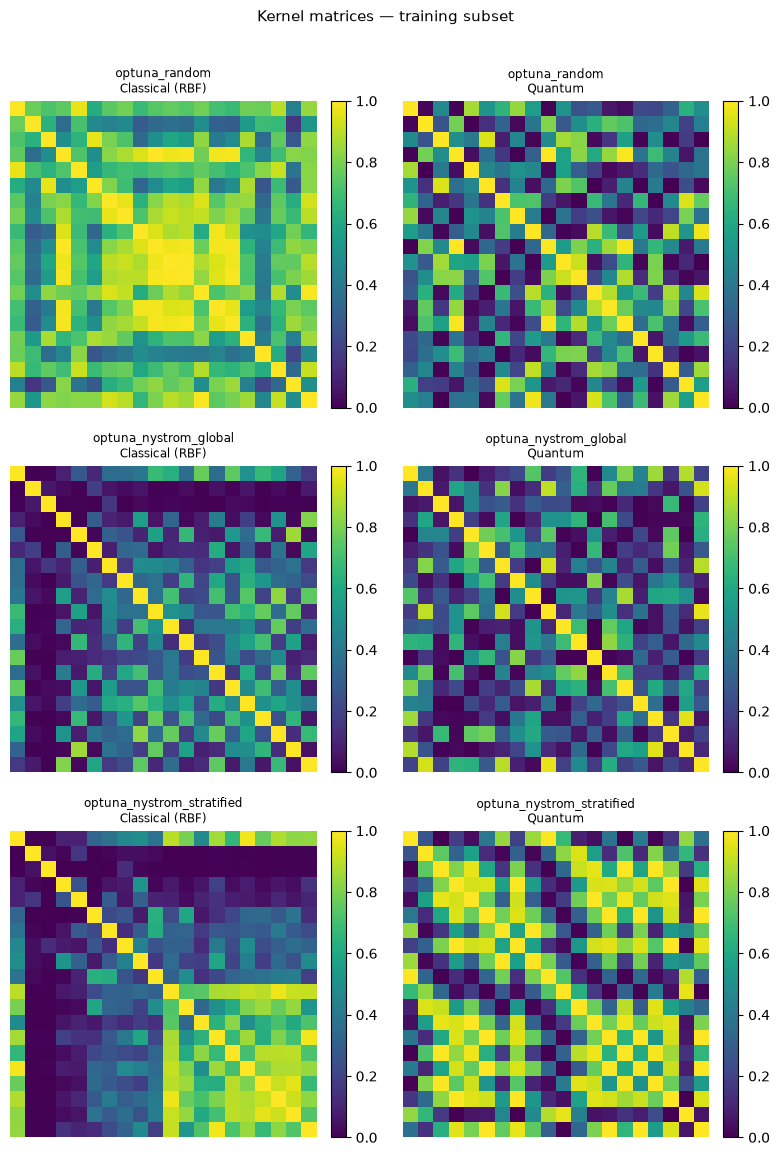

Saved → Results/Wisconsin breast dataset/kernel_heatmaps.png


In [6]:
# ── 5. Visualizations ──────────────────────────────────────────────────────────

plot_accuracy(summary)
plot_g_best(summary)
plot_kernel_heatmaps(summary, max_show=3)